✅ Data loaded successfully


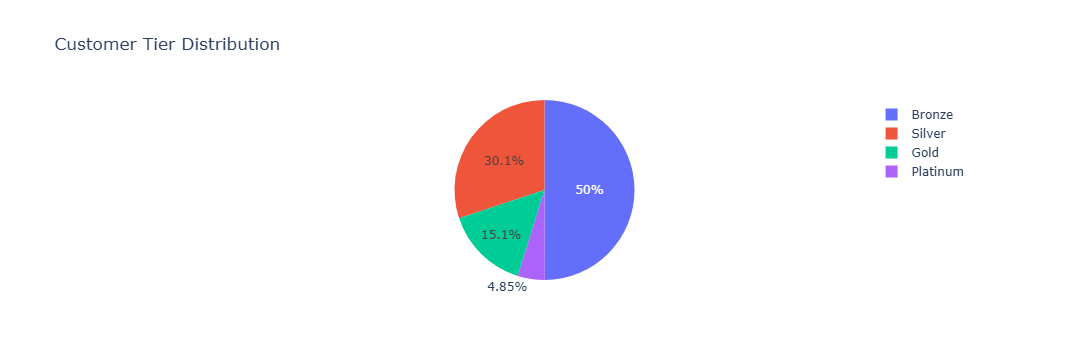

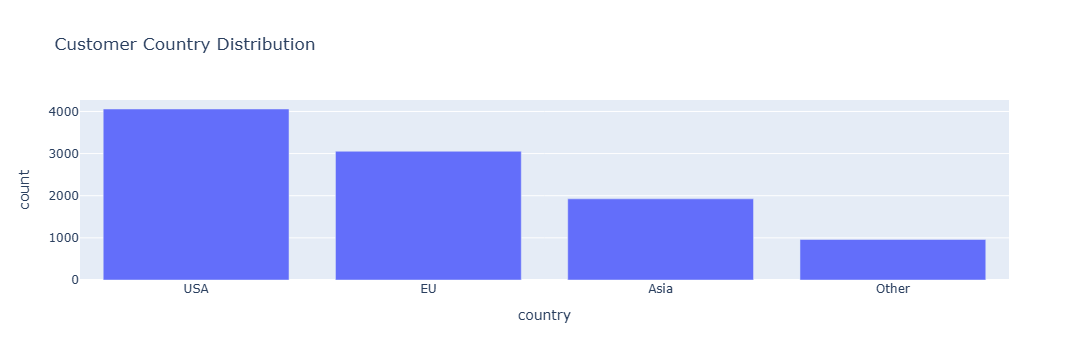

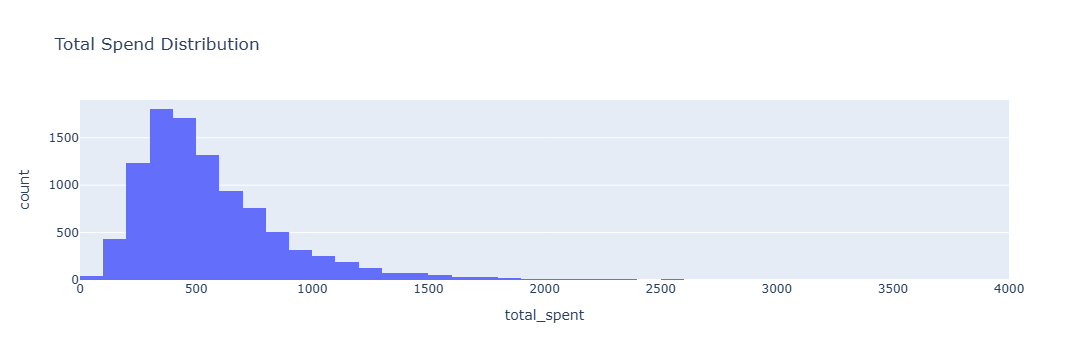

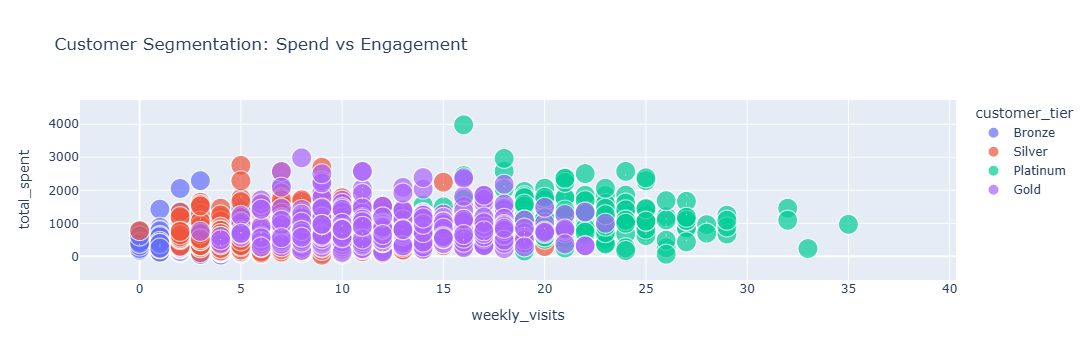

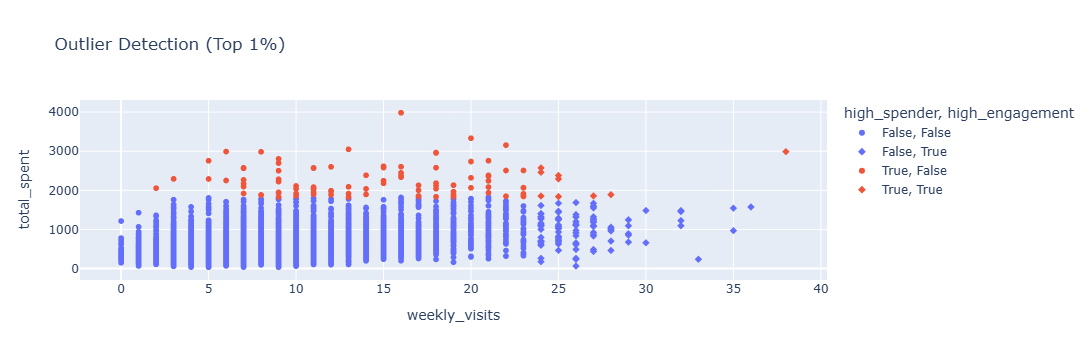

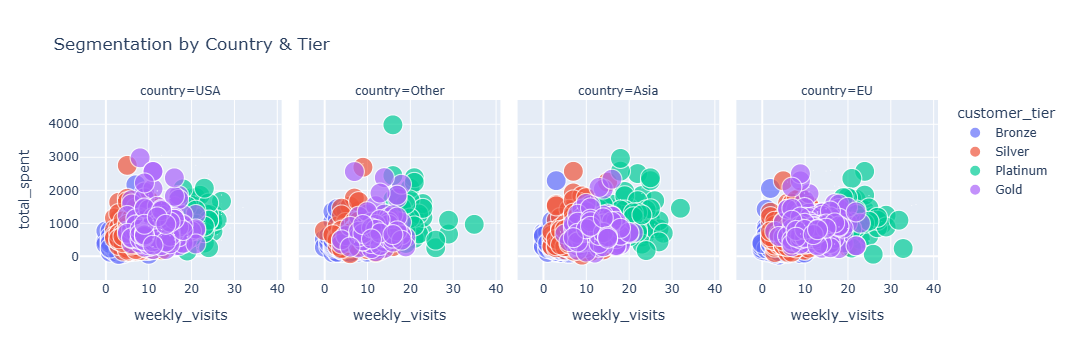


📊 Advanced Summary by Tier:
               total_spent                           weekly_visits             \
                      mean    median      max    min          mean median max   
customer_tier                                                                   
Bronze          407.923473   376.710  2292.01  32.83      4.948549    5.0  15   
Gold            813.386146   744.545  3332.89  67.22     12.038411   12.0  26   
Platinum       1161.850371  1093.780  3983.04  63.75     20.311340   20.0  38   
Silver          618.978153   572.330  2755.31  34.98      7.968771    8.0  20   

              num_promotions_responded        
                                  mean   sum  
customer_tier                                 
Bronze                        0.478278  2389  
Gold                          0.481457   727  
Platinum                      0.482474   234  
Silver                        0.481063  1448  


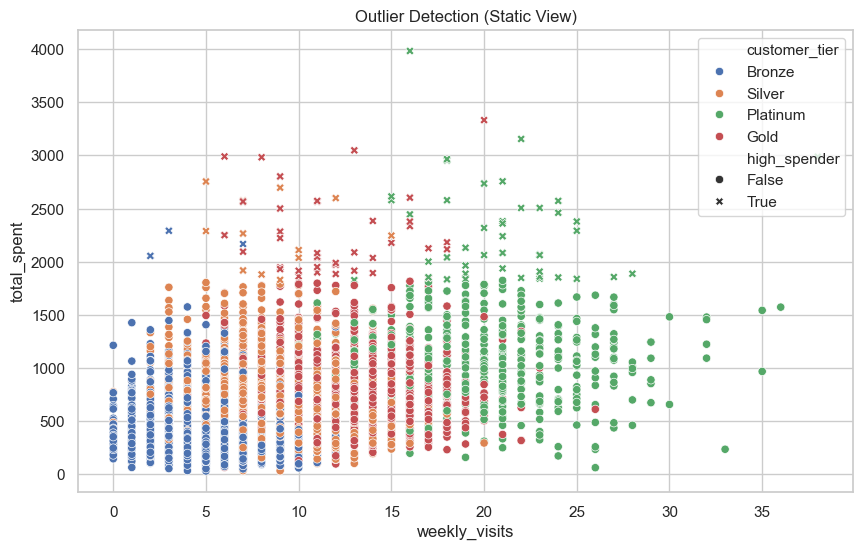


✅ Final dataset saved: ../data/full_dataset_10k.csv

🔍 Missing Values:
customer_id                 0
name                        0
gender                      0
age                         0
country                     0
signup_date                 0
customer_tier               0
months_since_signup         0
churned                     0
CLV                         0
next_purchase_prob          0
total_spent                 0
weekly_visits               0
session_time_minutes        0
page_views                  0
app_opens                   0
num_promotions_responded    0
high_spender                0
high_engagement             0
dtype: int64

🔍 Data Types:
customer_id                          int64
name                                object
gender                              object
age                                  int64
country                             object
signup_date                 datetime64[ns]
customer_tier                       object
months_since_signup          

In [7]:
# Step 6: Final FAANG-Level EDA & Segmentation (Clean + Future-Proof)

# -----------------------------
# Step 0: Imports
# -----------------------------
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# -----------------------------
# Step 1: Load datasets safely
# -----------------------------
data_folder = "../data/"

files = [
    "customer_profiles_10k.csv",
    "purchase_history_10k.csv",
    "engagement_behavior_10k.csv",
    "marketing_promotions_10k.csv"
]

for f in files:
    path = os.path.join(data_folder, f)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {f}")

customer_profiles = pd.read_csv(os.path.join(data_folder,"customer_profiles_10k.csv"))
purchase_history = pd.read_csv(os.path.join(data_folder,"purchase_history_10k.csv"))
engagement_behavior = pd.read_csv(os.path.join(data_folder,"engagement_behavior_10k.csv"))
marketing_promotions = pd.read_csv(os.path.join(data_folder,"marketing_promotions_10k.csv"))

print("✅ Data loaded successfully")

# -----------------------------
# Step 2: Data type corrections
# -----------------------------
customer_profiles["signup_date"] = pd.to_datetime(customer_profiles["signup_date"])

# -----------------------------
# Step 3: Feature Aggregation
# -----------------------------
# Total spend
total_spent = (
    purchase_history
    .groupby("customer_id", as_index=False)["order_amount"]
    .sum()
    .rename(columns={"order_amount": "total_spent"})
)

# Promotions responded
num_promotions = (
    marketing_promotions
    .groupby("customer_id", as_index=False)["responded"]
    .sum()
    .rename(columns={"responded": "num_promotions_responded"})
)

# -----------------------------
# Step 4: Merge datasets
# -----------------------------
df = (
    customer_profiles
    .merge(total_spent, on="customer_id", how="left")
    .merge(engagement_behavior, on="customer_id", how="left")
    .merge(num_promotions, on="customer_id", how="left")
)

# -----------------------------
# Step 5: Handle missing values (NO WARNINGS)
# -----------------------------
df["total_spent"] = df["total_spent"].fillna(0)
df["num_promotions_responded"] = df["num_promotions_responded"].fillna(0)

# Realistic imputation
df["session_time_minutes"] = df["session_time_minutes"].fillna(df["session_time_minutes"].median())
df["page_views"] = df["page_views"].fillna(df["page_views"].median())

# -----------------------------
# Step 6: Outlier Detection
# -----------------------------
spend_threshold = df["total_spent"].quantile(0.99)
visit_threshold = df["weekly_visits"].quantile(0.99)

df["high_spender"] = df["total_spent"] >= spend_threshold
df["high_engagement"] = df["weekly_visits"] >= visit_threshold

# -----------------------------
# Step 7: Interactive Visualizations
# -----------------------------

# Tier Distribution
fig = px.pie(df, names="customer_tier", title="Customer Tier Distribution")
fig.show()

# Country Distribution
country_df = df["country"].value_counts().reset_index()
country_df.columns = ["country", "count"]

fig = px.bar(country_df, x="country", y="count",
             title="Customer Country Distribution")
fig.show()

# Spend Distribution
fig = px.histogram(df, x="total_spent", nbins=50,
                   title="Total Spend Distribution")
fig.show()

# Engagement vs Spend
fig = px.scatter(
    df,
    x="weekly_visits",
    y="total_spent",
    color="customer_tier",
    size="num_promotions_responded",
    hover_data=["customer_id", "name", "country"],
    title="Customer Segmentation: Spend vs Engagement"
)
fig.show()

# Outlier Visualization
fig = px.scatter(
    df,
    x="weekly_visits",
    y="total_spent",
    color="high_spender",
    symbol="high_engagement",
    hover_data=["customer_id", "customer_tier"],
    title="Outlier Detection (Top 1%)"
)
fig.show()

# Faceted view (very powerful for analysis)
fig = px.scatter(
    df,
    x="weekly_visits",
    y="total_spent",
    color="customer_tier",
    facet_col="country",
    size="num_promotions_responded",
    title="Segmentation by Country & Tier"
)
fig.show()

# -----------------------------
# Step 8: Summary Analytics
# -----------------------------
summary = df.groupby("customer_tier").agg({
    "total_spent": ["mean","median","max","min"],
    "weekly_visits": ["mean","median","max"],
    "num_promotions_responded": ["mean","sum"]
})

print("\n📊 Advanced Summary by Tier:")
print(summary)

# -----------------------------
# Step 9: Static Outlier Plot
# -----------------------------
plt.figure()
sns.scatterplot(
    data=df,
    x="weekly_visits",
    y="total_spent",
    hue="customer_tier",
    style="high_spender"
)
plt.title("Outlier Detection (Static View)")
plt.show()

# -----------------------------
# Step 10: Save Final Dataset
# -----------------------------
output_path = os.path.join(data_folder, "full_dataset_10k.csv")
df.to_csv(output_path, index=False)

print(f"\n✅ Final dataset saved: {output_path}")

# -----------------------------
# Step 11: Data Quality Check
# -----------------------------
print("\n🔍 Missing Values:")
print(df.isna().sum())

print("\n🔍 Data Types:")
print(df.dtypes)

print("\n Step 6 Completed Successfully ")